In [67]:
import cv2

In [68]:
import os
import json
import re
import argparse
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [69]:
"""Common Series data structure used by the master plotting functions.

A Series is a plain, pre-extracted dataset: no file/JSON handling happens here or in
the master plotting functions below. Extractor functions (e.g. extract_patient_field_series,
or the coil-detection extraction in plot_coil_detection) are responsible for reading
JSON files and building Series objects; the master functions only ever consume them.
"""

from dataclasses import dataclass, field
from typing import List, Optional, Tuple


@dataclass
class Series:
    """One plottable dataset.

    Attributes:
        x: List of x values (typically frame numbers), sorted ascending.
        y: List of y values, same length as x, where y[i] corresponds to x[i].
        label: Used as the subplot title (grid function) / legend entry (overlay function).
        color: Optional explicit color. If None, matplotlib's default color cycle is used.
        style: One of "line", "step", "scatter", "area". "area" fills the region under
            the (step-interpolated) curve, useful for low-alpha background-style series
            like coil detection.
        y_limits: Optional (ymin, ymax) hint. Used directly as the axis limits in the
            grid function, and as the real-scale axis limits / normalization range in
            the overlay function.
        alpha: Opacity used when drawing the series (1.0 = opaque). Mainly relevant for
            style="area", where a low alpha (e.g. 0.2) gives a light background fill.
    """

    x: List[float]
    y: List[float]
    label: str
    color: Optional[str] = None
    style: str = "line"
    y_limits: Optional[Tuple[float, float]] = None
    alpha: float = 1.0

    def __post_init__(self):
        if len(self.x) != len(self.y):
            raise ValueError(
                f"Series '{self.label}': x and y must be the same length "
                f"(got {len(self.x)} and {len(self.y)})"
            )
        if self.style not in ("line", "step", "scatter", "area"):
            raise ValueError(
                f"Series '{self.label}': style must be 'line', 'step', 'scatter' or 'area' "
                f"(got {self.style!r})"
            )


In [70]:
def extract_patient_field_series(folder_path, field, label, color=None, style="line"):
    """Scan folder_path for '*_<frame>_<date>_<time>.json' files and build a Series
    from the 'patient.<field>' value in each file (e.g. field='height' or 'weight').

    Replaces the duplicated JSON-scanning code that used to live separately inside
    visualize_heights and visualize_weights.

    Args:
        folder_path: Directory containing the patient json files.
        field: Key to read from the 'patient' object (e.g. "height", "weight").
        label: Label to attach to the resulting Series (subplot title / legend entry).
        color: Optional explicit color for the Series.
        style: Plot style for the Series ("line", "step", or "scatter").

    Returns:
        A Series with x=frame numbers (sorted) and y=field values.
    """
    json_files = list(Path(folder_path).glob("*.json"))
    if not json_files:
        raise ValueError(f"No JSON files found in {folder_path}")

    data = []
    for json_file in json_files:
        match = re.search(r'_(\d+)_\d+_\d+\.json$', json_file.name)
        if not match:
            continue

        frame_number = int(match.group(1))
        try:
            with open(json_file, 'r') as f:
                json_data = json.load(f)
        except Exception as e:
            print(f"Error reading {json_file.name}: {e}")
            continue

        patient = json_data.get('patient', {})
        if field not in patient:
            print(f"Warning: 'patient.{field}' not found in {json_file.name}")
            continue

        data.append((frame_number, patient[field]))

    if not data:
        raise ValueError(f"No valid '{field}' data found in JSON files in {folder_path}")

    data.sort(key=lambda item: item[0])
    frame_numbers = [d[0] for d in data]
    values = [d[1] for d in data]

    return Series(x=frame_numbers, y=values, label=label, color=color, style=style)


In [71]:
import math


def plot_series_grid(*panels, ncols=2, figsize_per_plot=(7, 5), save_path=None, show=True):
    """Plot each panel argument as its own subplot, arranged in a grid.

    Each argument passed in `*panels` corresponds to exactly one subplot, and can be
    either:
      - a Series - drawn with that series' own style/color/y_limits and labeled via
        the subplot title (this does not auto-generate extra subplots, e.g. no
        automatic histogram; pass a second Series explicitly for that), or
      - a callable accepting a single `ax` keyword argument (e.g.
        `functools.partial(some_panel_fn, ..., )`) - called as `panel(ax=ax)`, fully
        responsible for drawing/labeling/titling that subplot itself. Useful for
        composing more complex, multi-line panels (e.g. plot_landmark_variation_x/y)
        side by side using this grid layout.

    Args:
        *panels: One or more Series objects and/or `ax`-accepting callables, one per subplot.
        ncols: Number of subplots per row (default 2).
        figsize_per_plot: (width, height) inches used per subplot when sizing the figure.
        save_path: Optional path to save the resulting figure.
        show: Whether to call plt.show() at the end.

    Returns:
        The matplotlib Figure object.
    """
    if not panels:
        raise ValueError("plot_series_grid requires at least one Series or callable argument")

    n = len(panels)
    ncols = max(1, min(ncols, n))
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols, figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows)
    )
    axes = np.atleast_1d(axes).flatten()

    for ax, panel in zip(axes, panels):
        if callable(panel) and not isinstance(panel, Series):
            # The callable owns this subplot entirely: drawing, labels, title, limits.
            panel(ax=ax)
            continue

        s = panel
        if s.style == "line":
            ax.plot(s.x, s.y, marker='o', linestyle='-', linewidth=2, markersize=4,
                    color=s.color, alpha=s.alpha)
        elif s.style == "step":
            ax.step(s.x, s.y, where="post", linewidth=2, color=s.color, alpha=s.alpha)
        elif s.style == "scatter":
            ax.scatter(s.x, s.y, color=s.color, alpha=s.alpha)
        elif s.style == "area":
            ax.fill_between(s.x, s.y, step="post", color=s.color, alpha=s.alpha, linewidth=0)

        ax.set_xlabel("Frame Number", fontsize=12)
        ax.set_ylabel(s.label, fontsize=12)
        ax.set_title(s.label, fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        if s.y_limits is not None:
            ax.set_ylim(*s.y_limits)

    # Hide any unused axes when the last row isn't fully filled.
    for ax in axes[n:]:
        ax.axis("off")

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150)
    if show:
        plt.show()

    return fig


In [72]:
def _draw_series(ax, s):
    """Draw a single Series onto ax using its style, returning the plotted line/artist."""
    if s.style == "line":
        artist, = ax.plot(s.x, s.y, marker='o', linestyle='-', linewidth=2, markersize=3,
                           color=s.color, alpha=s.alpha, label=s.label)
    elif s.style == "step":
        artist, = ax.step(s.x, s.y, where="post", linewidth=2, color=s.color, alpha=s.alpha,
                           label=s.label)
    elif s.style == "scatter":
        artist = ax.scatter(s.x, s.y, color=s.color, alpha=s.alpha, label=s.label)
    elif s.style == "area":
        # Light, low-alpha filled region under a step-interpolated curve - good for
        # background-style series (e.g. coil detection) that shouldn't visually compete
        # with sharper line/step series on the same overlay.
        artist = ax.fill_between(s.x, s.y, step="post", color=s.color, alpha=s.alpha,
                                  linewidth=0, label=s.label)
    else:
        raise ValueError(f"Unknown style {s.style!r} for series {s.label!r}")
    return artist


def plot_series_overlay(*series, max_real_scale_axes=2, figsize=(12, 6), save_path=None, show=True):
    """Overlay all given Series on a single figure, auto-scaling as needed.

    Scaling strategy (chosen automatically based on how many series are passed):
      - If len(series) <= max_real_scale_axes + 1 (default: primary axis + 2 twins = 3
        series total), each series gets its own y-axis via ax.twinx() (with offset
        spines for the 3rd+ axis), preserving each series' real units/scale. A
        series' own `y_limits` is applied to its axis when provided.
      - Otherwise, every series is min-max normalized onto one shared 0-1 y-axis, using
        `y_limits` as the normalization range if given, else the series' own min/max.
        Each legend label is annotated with the original value range, e.g.
        "Height (120-210 mm)".

    Args:
        *series: One or more Series objects to overlay.
        max_real_scale_axes: Max number of *additional* (twin) real-scale axes beyond
            the primary axis before falling back to normalization.
        figsize: Figure size in inches.
        save_path: Optional path to save the resulting figure.
        show: Whether to call plt.show() at the end.

    Returns:
        The matplotlib Figure object.
    """
    if not series:
        raise ValueError("plot_series_overlay requires at least one Series argument")

    fig, primary_ax = plt.subplots(figsize=figsize)

    use_twin_axes = len(series) <= max_real_scale_axes + 1

    artists = []
    if use_twin_axes:
        for i, s in enumerate(series):
            ax = primary_ax if i == 0 else primary_ax.twinx()
            if i > 1:
                # Offset the spine of each extra twin axis so it doesn't overlap the first twin.
                ax.spines["right"].set_position(("axes", 1 + 0.12 * (i - 1)))
            artists.append(_draw_series(ax, s))
            ax.set_ylabel(s.label, **({"color": s.color} if s.color else {}))
            if s.y_limits is not None:
                ax.set_ylim(*s.y_limits)
        primary_ax.set_xlabel("Frame Number")
        primary_ax.set_title("Series Overlay (real scale per series)")
    else:
        for s in series:
            y_min, y_max = s.y_limits if s.y_limits is not None else (min(s.y), max(s.y))
            span = (y_max - y_min) or 1  # avoid divide-by-zero for constant series
            normalized_y = [(v - y_min) / span for v in s.y]
            normalized_series = Series(
                x=s.x, y=normalized_y, label=f"{s.label} ({y_min:g}-{y_max:g})",
                color=s.color, style=s.style, alpha=s.alpha,
            )
            artists.append(_draw_series(primary_ax, normalized_series))
        primary_ax.set_ylim(-0.05, 1.05)
        primary_ax.set_ylabel("Normalized value (0-1)")
        primary_ax.set_xlabel("Frame Number")
        primary_ax.set_title("Series Overlay (normalized 0-1)")

    primary_ax.grid(True, alpha=0.3)

    # Combine legend entries across all axes (primary + any twins).
    labels = [a.get_label() for a in artists]
    primary_ax.legend(artists, labels, loc="center left", bbox_to_anchor=(1.05, 0.5), fontsize=9)

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    if show:
        plt.show()

    return fig


In [73]:
def _plot_value_and_histogram(series, value_label):
    """Shared two-panel (line + histogram) rendering used by visualize_heights/visualize_weights."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(series.x, series.y, marker='o', linestyle='-', linewidth=2, markersize=4)
    ax1.set_xlabel('Frame Number', fontsize=12)
    ax1.set_ylabel(value_label, fontsize=12)
    ax1.set_title(f'{value_label} Over Frame Sequence', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    ax2.hist(series.y, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax2.set_xlabel(value_label, fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title(f'{value_label} Distribution', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


def _print_summary_stats(values, label, unit):
    mean = sum(values) / len(values)
    std = (sum((v - mean) ** 2 for v in values) / len(values)) ** 0.5
    print(f"\nSummary Statistics:")
    print(f"Total frames analyzed: {len(values)}")
    print(f"Min {label}: {min(values):.2f} {unit}")
    print(f"Max {label}: {max(values):.2f} {unit}")
    print(f"Mean {label}: {mean:.2f} {unit}")
    print(f"Std deviation: {std:.2f} {unit}")


def visualize_heights(folder_path):
    """Visualize height data from JSON files in a folder (line plot + histogram).

    Thin wrapper around extract_patient_field_series - no more duplicated JSON
    parsing here (see the old copy-pasted version this replaces).
    """
    height_series = extract_patient_field_series(folder_path, "height", "Height (mm)")
    _plot_value_and_histogram(height_series, "Height (mm)")
    _print_summary_stats(height_series.y, "height", "mm")


def visualize_weights(folder_path):
    """Visualize weight data from JSON files in a folder (line plot + histogram).

    Thin wrapper around extract_patient_field_series - no more duplicated JSON
    parsing here (see the old copy-pasted version this replaces).
    """
    weight_series = extract_patient_field_series(folder_path, "weight", "Weight (kg)")
    _plot_value_and_histogram(weight_series, "Weight (kg)")
    _print_summary_stats(weight_series.y, "weight", "kg")


In [74]:
"""Plot coil detection status (detected=1 / not detected=0) per frame.

Reads a folder of inference json files (e.g. ``Inference_Frame_<frame_number>_*.json``),
inspects the ``coils`` list in each file for coil ``type`` values, maps those values back
to human readable coil names using ``coils_dict.json``, and plots one detection timeline
per coil across frame numbers using a fixed color per coil.

The JSON-scanning helpers (load_coils_dict / extract_frame_number / get_detected_coil_types /
collect_frame_data) are unchanged from before; only the final drawing step now builds one
Series per coil and delegates to the master plot_series_overlay function.
"""

FRAME_NUMBER_RE = re.compile(r"frame_(\d+)", re.IGNORECASE)


def load_coils_dict(coils_dict_path):
    """Load coils_dict.json and return {coil_name: (coil_type, color)}."""
    with open(coils_dict_path, "r") as f:
        raw = json.load(f)

    coils = {}
    for name, value in raw.items():
        if isinstance(value, dict):
            coils[name] = (value["type"], value.get("color", "#333333"))
        else:
            # Backwards compatibility with the plain {name: type} format.
            coils[name] = (value, "#333333")
    return coils


def extract_frame_number(file_path):
    """Extract the integer frame number from a file name."""
    match = FRAME_NUMBER_RE.search(file_path.name)
    if not match:
        return None
    return int(match.group(1))


def get_detected_coil_types(json_path):
    """Return the set of coil type strings present in an inference json file."""
    with open(json_path, "r") as f:
        data = json.load(f)

    detected = set()
    for coil in data.get("coils", []) or []:
        coil_type = coil.get("type")
        if coil_type:
            detected.add(coil_type)
    return detected


def collect_frame_data(folder_path):
    """Scan folder for inference frame jsons and return sorted (frame_number, detected_types)."""
    folder = Path(folder_path)
    frame_data = []
    for json_path in folder.glob("*.json"):
        frame_number = extract_frame_number(json_path)
        if frame_number is None:
            continue
        detected_types = get_detected_coil_types(json_path)
        frame_data.append((frame_number, detected_types))

    frame_data.sort(key=lambda item: item[0])
    return frame_data


def build_coil_series(folder_path, coils_dict_path="coils_dict.json"):
    """Build one Series per detected coil (x=frame numbers, y=0/1 detection)."""
    coils_dict = load_coils_dict(coils_dict_path)
    frame_data = collect_frame_data(folder_path)

    if not frame_data:
        raise ValueError(f"No inference_frame_*.json files with a frame number found in {folder_path}")

    frame_numbers = [frame_number for frame_number, _ in frame_data]

    # Only build a Series for coils that are known in coils_dict.json AND detected in
    # at least one frame.
    all_detected_types = set().union(*(detected for _, detected in frame_data))
    coil_names = [
        coil_name
        for coil_name, (coil_type, _) in coils_dict.items()
        if coil_type in all_detected_types
    ]

    if not coil_names:
        raise ValueError("None of the coils in coils_dict.json were detected in any frame")

    coil_series = []
    for coil_name in coil_names:
        coil_type, color = coils_dict[coil_name]
        detection = [
            1 if coil_type in detected_types else 0 for _, detected_types in frame_data
        ]
        coil_series.append(
            Series(x=frame_numbers, y=detection, label=coil_name, color=color,
                   style="area", y_limits=(0, 1), alpha=0.4)
        )
    return coil_series


def plot_coil_detection(folder_path, coils_dict_path="coils_dict.json", save_path=None, show=True):
    """Plot per-coil detection (1/0) across frame numbers found in folder_path.

    All coils are drawn on a single overlay plot (via plot_series_overlay), colored
    using the fixed color assigned in coils_dict.json, and labeled via the legend.
    Only coils that are detected in at least one frame are plotted.

    Args:
        folder_path: Directory containing inference_frame_<frame_number>_*.json files.
        coils_dict_path: Path to coils_dict.json mapping coil name -> {type, color}.
        save_path: Optional path to save the resulting figure.
        show: Whether to call plt.show() at the end.

    Returns:
        The matplotlib Figure object.
    """
    coil_series = build_coil_series(folder_path, coils_dict_path)

    # All coil series are 0/1, so real-scale (twin-axis) mode is irrelevant here; force
    # normalization mode regardless of coil count by passing max_real_scale_axes=0.
    fig = plot_series_overlay(*coil_series, max_real_scale_axes=0, save_path=save_path, show=show)
    fig.axes[0].set_title("Coil Detection per Frame")
    return fig


In [75]:
import math
import functools

"""Plot frame-to-frame variation (absolute displacement) of body landmarks.

Reads patient.allMarkers from each json file in a folder (same *_<frame>_<date>_<time>.json
naming convention as extract_patient_field_series), matches the requested landmark names
against whatever keys actually exist in allMarkers (allowing for minor naming differences,
e.g. "righthip" vs "RIGHT_HIP_JOINT"), and plots the frame-to-frame absolute movement of
each landmark's x and y coordinate as two separate panels. Each landmark gets a fixed
color, and lines are labeled inline (either at their peak, when a threshold is given and
they cross it, or at their right-hand end otherwise) instead of via a legend box.
"""

# Landmark name -> index, as provided. The index is only used to assign each landmark a
# stable, fixed color (from a large categorical palette) that stays consistent across
# calls/plots regardless of which subset of landmarks is actually detected.
LANDMARKS = {
    "nose": 0,
    "neck": 1,
    "rightshoulder": 2,
    "rightelbow": 3,
    "righthand": 4,
    "leftshoulder": 5,
    "leftelbow": 6,
    "lefthand": 7,
    "midhip": 8,
    "righthip": 9,
    "rightknee": 10,
    "rightfoot": 11,
    "lefthip": 12,
    "leftknee": 13,
    "leftfoot": 14,
    "righteye": 15,
    "lefteye": 16,
    "rightear": 17,
    "leftear": 18,
    "LBigToe": 19,
    "LSmallToe": 20,
    "LHeel": 21,
    "RBigToe": 22,
    "RSmallToe": 23,
    "RHeel": 24,
}

_LANDMARK_PALETTE = (
    list(plt.get_cmap("tab20").colors)
    + list(plt.get_cmap("tab20b").colors)
    + list(plt.get_cmap("tab20c").colors)
)
LANDMARK_COLORS = {
    name: _LANDMARK_PALETTE[index % len(_LANDMARK_PALETTE)] for name, index in LANDMARKS.items()
}


def _normalize_marker_name(name):
    """Uppercase and strip non-alphanumeric characters, so e.g. 'righthip' and
    'RIGHT_HIP' both normalize to 'RIGHTHIP', to tolerate minor naming differences."""
    return re.sub(r"[^A-Za-z0-9]", "", name).upper()


def _case_insensitive_get(d, key):
    """Look up key in dict d, falling back to a case-insensitive key match."""
    if key in d:
        return d[key]
    lowered = key.lower()
    for k, v in d.items():
        if k.lower() == lowered:
            return v
    return None


def _find_marker_key(target_name, marker_keys_by_norm):
    """Find the allMarkers key that best matches target_name, tolerating minor naming
    differences (e.g. 'righthip' matching 'RIGHT_HIP_JOINT'). Returns None if no
    reasonable match is found."""
    norm_target = _normalize_marker_name(target_name)
    if norm_target in marker_keys_by_norm:
        return marker_keys_by_norm[norm_target]

    # Fall back to prefix matching (e.g. norm_target 'RIGHTHIP' vs key 'RIGHTHIPJOINT'),
    # preferring the closest length match among candidates.
    candidates = [
        (norm_key, key)
        for norm_key, key in marker_keys_by_norm.items()
        if norm_key.startswith(norm_target) or norm_target.startswith(norm_key)
    ]
    if not candidates:
        return None
    candidates.sort(key=lambda item: abs(len(item[0]) - len(norm_target)))
    return candidates[0][1]


def collect_landmark_frame_data(folder_path):
    """Scan folder_path for patient json files and return a sorted list of
    (frame_number, {marker_name: (x, y)}) using the raw allMarkers key names."""
    frame_data = []
    for json_file in Path(folder_path).glob("*.json"):
        match = re.search(r'_(\d+)_\d+_\d+\.json$', json_file.name)
        if not match:
            continue
        frame_number = int(match.group(1))

        try:
            with open(json_file, "r") as f:
                payload = json.load(f)
        except Exception as e:
            print(f"Error reading {json_file.name}: {e}")
            continue

        patient = _case_insensitive_get(payload, "patient") or {}
        all_markers = _case_insensitive_get(patient, "allMarkers") or {}

        positions = {}
        for marker_name, coords in all_markers.items():
            x, y = coords.get("x"), coords.get("y")
            if x is not None and y is not None:
                positions[marker_name] = (x, y)

        frame_data.append((frame_number, positions))

    frame_data.sort(key=lambda item: item[0])
    return frame_data


def build_landmark_variation_series(folder_path, landmarks=LANDMARKS):
    """Build one Series per landmark per axis: x=frame numbers, y=frame-to-frame
    absolute displacement (|delta|) of that landmark's x coordinate / y coordinate.

    Landmarks that can't be matched to any key in allMarkers (in any frame), or that
    are present in fewer than 2 frames, are skipped with a warning.

    Returns:
        (series_x, series_y): two lists of Series, one entry per landmark, holding the
        frame-to-frame absolute variation of the x coordinate and y coordinate
        respectively.
    """
    frame_data = collect_landmark_frame_data(folder_path)
    if len(frame_data) < 2:
        raise ValueError(f"Need at least 2 frames with data to compute variation in {folder_path}")

    # Union of all marker key names ever seen, normalized -> raw key, used to resolve
    # each requested landmark name once.
    marker_keys_by_norm = {}
    for _, positions in frame_data:
        for marker_name in positions:
            marker_keys_by_norm.setdefault(_normalize_marker_name(marker_name), marker_name)

    series_x, series_y = [], []
    for landmark_name in landmarks:
        marker_key = _find_marker_key(landmark_name, marker_keys_by_norm)
        if marker_key is None:
            print(f"Warning: landmark '{landmark_name}' not found in allMarkers; skipping.")
            continue

        frame_numbers, xs, ys = [], [], []
        for frame_number, positions in frame_data:
            if marker_key in positions:
                frame_numbers.append(frame_number)
                x, y = positions[marker_key]
                xs.append(x)
                ys.append(y)

        if len(frame_numbers) < 2:
            print(f"Warning: landmark '{landmark_name}' found in fewer than 2 frames; skipping.")
            continue

        diff_frames = frame_numbers[1:]
        x_variation = [abs(xs[i] - xs[i - 1]) for i in range(1, len(xs))]
        y_variation = [abs(ys[i] - ys[i - 1]) for i in range(1, len(ys))]

        color = LANDMARK_COLORS[landmark_name]
        series_x.append(Series(x=diff_frames, y=x_variation, label=landmark_name, color=color, style="line"))
        series_y.append(Series(x=diff_frames, y=y_variation, label=landmark_name, color=color, style="line"))

    if not series_x:
        raise ValueError(f"None of the given landmarks were found in {folder_path}")

    return series_x, series_y


def build_landmark_position_series(folder_path, landmarks=LANDMARKS):
    """Build one Series per landmark per axis: x=frame numbers, y=that landmark's raw
    (normalized) x coordinate / y coordinate per frame - the absolute position, as
    opposed to build_landmark_variation_series's frame-to-frame difference.

    Landmarks that can't be matched to any key in allMarkers (in any frame) are
    skipped with a warning.

    Returns:
        (series_x, series_y): two lists of Series, one entry per landmark, holding the
        raw x coordinate and y coordinate per frame respectively.
    """
    frame_data = collect_landmark_frame_data(folder_path)
    if not frame_data:
        raise ValueError(f"No landmark data found in {folder_path}")

    marker_keys_by_norm = {}
    for _, positions in frame_data:
        for marker_name in positions:
            marker_keys_by_norm.setdefault(_normalize_marker_name(marker_name), marker_name)

    series_x, series_y = [], []
    for landmark_name in landmarks:
        marker_key = _find_marker_key(landmark_name, marker_keys_by_norm)
        if marker_key is None:
            print(f"Warning: landmark '{landmark_name}' not found in allMarkers; skipping.")
            continue

        frame_numbers, xs, ys = [], [], []
        for frame_number, positions in frame_data:
            if marker_key in positions:
                frame_numbers.append(frame_number)
                x, y = positions[marker_key]
                xs.append(x)
                ys.append(y)

        if not frame_numbers:
            print(f"Warning: landmark '{landmark_name}' found in no frames; skipping.")
            continue

        color = LANDMARK_COLORS[landmark_name]
        series_x.append(Series(x=frame_numbers, y=xs, label=landmark_name, color=color, style="line"))
        series_y.append(Series(x=frame_numbers, y=ys, label=landmark_name, color=color, style="line"))

    if not series_x:
        raise ValueError(f"None of the given landmarks were found in {folder_path}")

    return series_x, series_y


def _draw_landmark_panel(ax, series_list, title, ylabel, threshold):
    """Draw all landmark Series for one axis (x or y) onto ax, optionally drawing a
    threshold line and labeling only the landmarks that cross it (at their peak).
    When threshold is None, every landmark is instead labeled inline at its line end.
    Shared by the variation and position panel-drawers below.
    """
    for s in series_list:
        _draw_series(ax, s)

    x_min = min(s.x[0] for s in series_list)
    x_max = max(s.x[-1] for s in series_list)
    ax.set_xlim(x_min, x_max + max(1, (x_max - x_min) * 0.12))

    if threshold is not None:
        ax.axhline(threshold, color="red", linestyle="--", linewidth=1.5)
        ax.text(x_max, threshold, f"  {threshold:.1%} threshold", color="red",
                fontsize=8, va="center", clip_on=False)
        for s in series_list:
            peak_idx = max(range(len(s.y)), key=lambda i: s.y[i])
            peak_val = s.y[peak_idx]
            if peak_val >= threshold:
                ax.annotate(
                    s.label, xy=(s.x[peak_idx], peak_val), xytext=(0, 6),
                    textcoords="offset points", color=s.color, ha="center",
                    fontsize=8, fontweight="bold", clip_on=False,
                )
    else:
        for s in series_list:
            ax.annotate(
                s.label, xy=(s.x[-1], s.y[-1]), xytext=(6, 0),
                textcoords="offset points", color=s.color, va="center",
                fontsize=8, fontweight="bold", clip_on=False,
            )

    ax.set_xlabel("Frame Number")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)


def _draw_landmark_variation_panel(ax, series_list, axis_label, threshold):
    """Draw the frame-to-frame variation panel for one axis (x or y) onto ax.
    Shared by plot_landmark_variation_x and plot_landmark_variation_y.
    """
    _draw_landmark_panel(
        ax, series_list, f"Landmark Variation - {axis_label}",
        f"Frame-to-Frame {axis_label} Displacement", threshold,
    )


def _landmark_variation_axis_plot(axis_index, axis_label, folder_path, landmarks, threshold,
                                   figsize, ax, save_path, show):
    """Shared implementation backing plot_landmark_variation_x/y.

    If `ax` is given, draws onto it and returns that ax (for composing side by side
    via plot_series_grid, since plot_series_grid calls callables as `panel(ax=ax)`).
    Otherwise creates, optionally saves/shows, and returns its own standalone Figure.
    """
    if threshold is not None and threshold > 1:
        threshold = threshold / 100.0

    series_x, series_y = build_landmark_variation_series(folder_path, landmarks)
    series_list = series_x if axis_index == 0 else series_y

    if ax is not None:
        _draw_landmark_variation_panel(ax, series_list, axis_label, threshold)
        return ax

    fig, standalone_ax = plt.subplots(figsize=figsize)
    _draw_landmark_variation_panel(standalone_ax, series_list, axis_label, threshold)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    if show:
        plt.show()

    return fig


def plot_landmark_variation_x(folder_path, landmarks=LANDMARKS, threshold=None,
                               figsize=(8, 6), ax=None, save_path=None, show=True):
    """Plot frame-to-frame absolute X displacement for each of `landmarks`, found in
    patient.allMarkers under folder_path. Each landmark is drawn as its own line with
    a fixed color (see LANDMARK_COLORS).

    Args:
        folder_path: Directory containing patient json files.
        landmarks: Mapping of landmark name -> index (defaults to the standard 25
            body landmarks); only used to pick a fixed, stable color per landmark.
        threshold: Optional fraction of the normalized coordinate range (e.g. 0.05 for
            5%; values > 1 are treated as a percentage, e.g. 5 -> 0.05). If given, a
            horizontal dashed threshold line is drawn, and only landmarks whose peak
            displacement reaches/exceeds the threshold are labeled, at their peak
            point. If None, no threshold line is drawn and every landmark is labeled
            inline at the end of its line instead.
        figsize: Figure size in inches, used only when `ax` is not given.
        ax: Optional existing Axes to draw onto instead of creating a new figure -
            pass this function (via functools.partial) to plot_series_grid to lay it
            out side by side with plot_landmark_variation_y, e.g.:
                plot_series_grid(
                    functools.partial(plot_landmark_variation_x, folder_path, threshold=0.05),
                    functools.partial(plot_landmark_variation_y, folder_path, threshold=0.05),
                )
        save_path: Optional path to save the resulting figure (ignored if `ax` is given).
        show: Whether to call plt.show() at the end (ignored if `ax` is given).

    Returns:
        The matplotlib Figure object, or `ax` itself if `ax` was given.
    """
    return _landmark_variation_axis_plot(
        0, "X", folder_path, landmarks, threshold, figsize, ax, save_path, show
    )


def plot_landmark_variation_y(folder_path, landmarks=LANDMARKS, threshold=None,
                               figsize=(8, 6), ax=None, save_path=None, show=True):
    """Plot frame-to-frame absolute Y displacement for each of `landmarks`, found in
    patient.allMarkers under folder_path. See plot_landmark_variation_x for full
    argument documentation - identical, except this plots the Y coordinate variation.
    """
    return _landmark_variation_axis_plot(
        1, "Y", folder_path, landmarks, threshold, figsize, ax, save_path, show
    )


def _draw_landmark_position_subplot(ax, s, threshold):
    """Draw a single landmark's position Series onto its own subplot ax, used when
    composing a grid of one-subplot-per-landmark position plots via plot_series_grid.
    Optionally draws a horizontal threshold reference line (no peak labeling needed
    here, since each landmark already has its own titled subplot).
    """
    _draw_series(ax, s)
    if threshold is not None:
        ax.axhline(threshold, color="red", linestyle="--", linewidth=1, alpha=0.8)
    ax.set_xlabel("Frame Number", fontsize=12)
    ax.set_ylabel(s.label, fontsize=12)
    ax.set_title(s.label, fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.3)


def plot_landmark_position_x(folder_path, landmarks=LANDMARKS, threshold=None, ncols=2,
                              figsize_per_plot=(7, 5), save_path=None, show=True):
    """Plot each landmark's absolute (raw, normalized) X position per frame as its own
    subplot - one subplot per landmark, arranged in a grid via plot_series_grid -
    instead of overlaying every landmark onto a single shared axis.

    Args:
        folder_path: Directory containing patient json files.
        landmarks: Mapping of landmark name -> index (defaults to the standard 25
            body landmarks); only used to pick a fixed, stable color per landmark.
        threshold: Optional fraction of the normalized coordinate range (e.g. 0.05 for
            5%; values > 1 are treated as a percentage, e.g. 5 -> 0.05). If given, a
            horizontal dashed threshold reference line is drawn on every landmark's
            subplot. If None, no threshold line is drawn.
        ncols: Number of subplots per row (default 2), forwarded to plot_series_grid.
        figsize_per_plot: (width, height) inches per subplot, forwarded to plot_series_grid.
        save_path: Optional path to save the resulting figure.
        show: Whether to call plt.show() at the end.

    Returns:
        The matplotlib Figure object (from plot_series_grid).
    """
    if threshold is not None and threshold > 1:
        threshold = threshold / 100.0

    series_x, _ = build_landmark_position_series(folder_path, landmarks)
    panels = [functools.partial(_draw_landmark_position_subplot, s=s, threshold=threshold) for s in series_x]

    return plot_series_grid(
        *panels, ncols=ncols, figsize_per_plot=figsize_per_plot, save_path=save_path, show=show
    )


def plot_landmark_position_y(folder_path, landmarks=LANDMARKS, threshold=None, ncols=2,
                              figsize_per_plot=(7, 5), save_path=None, show=True):
    """Plot each landmark's absolute (raw, normalized) Y position per frame as its own
    subplot - one subplot per landmark, arranged in a grid via plot_series_grid. See
    plot_landmark_position_x for full argument documentation - identical, except this
    plots the Y coordinate position.
    """
    if threshold is not None and threshold > 1:
        threshold = threshold / 100.0

    _, series_y = build_landmark_position_series(folder_path, landmarks)
    panels = [functools.partial(_draw_landmark_position_subplot, s=s, threshold=threshold) for s in series_y]

    return plot_series_grid(
        *panels, ncols=ncols, figsize_per_plot=figsize_per_plot, save_path=save_path, show=show
    )


In [76]:
FOLDER_PATH = "/home/gokul/defects/mr_8894/WorkflowCamera"


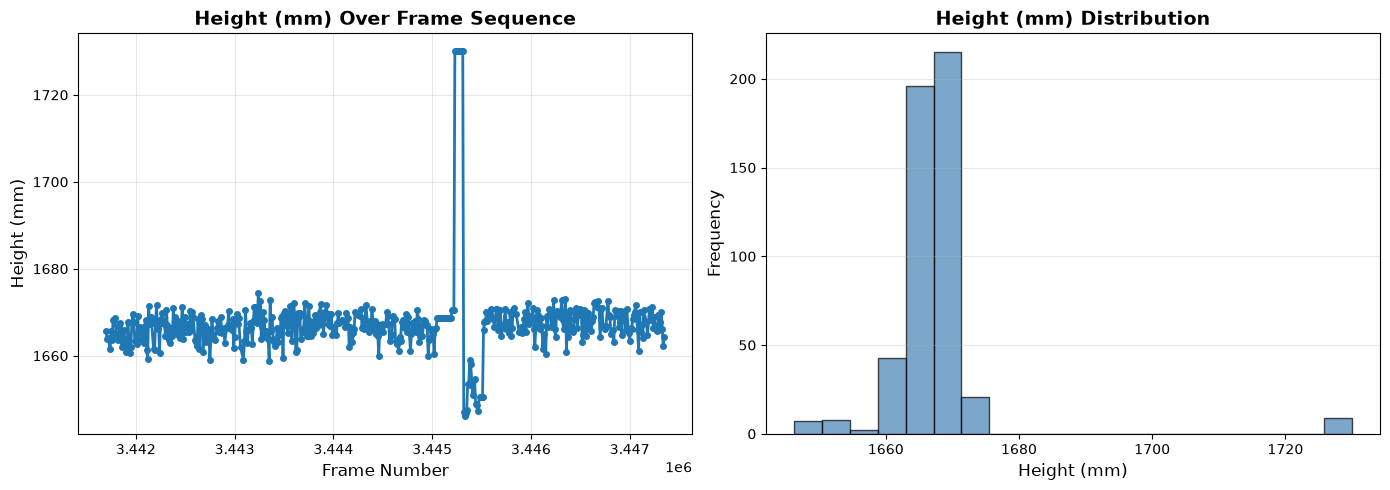


Summary Statistics:
Total frames analyzed: 501
Min height: 1646.22 mm
Max height: 1730.02 mm
Mean height: 1667.52 mm
Std deviation: 9.42 mm


In [77]:
visualize_heights(FOLDER_PATH)


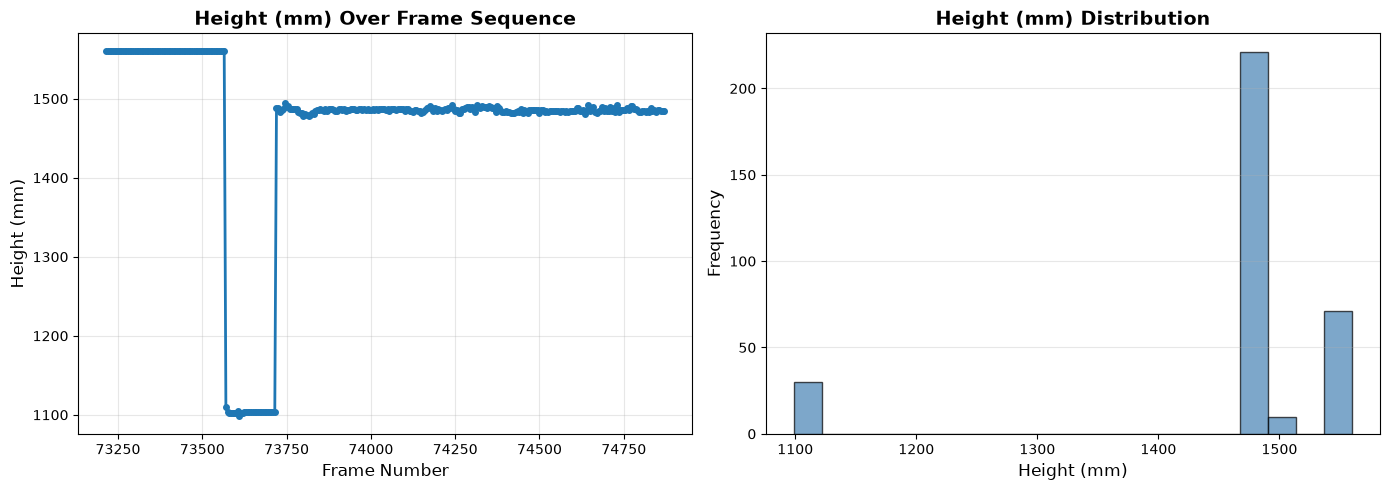


Summary Statistics:
Total frames analyzed: 332
Min height: 1098.99 mm
Max height: 1560.01 mm
Mean height: 1467.09 mm
Std deviation: 118.49 mm


In [78]:
FOLDER_PATH = "/home/gokul/defects/mr00389746/0704-0705"
visualize_heights(FOLDER_PATH)


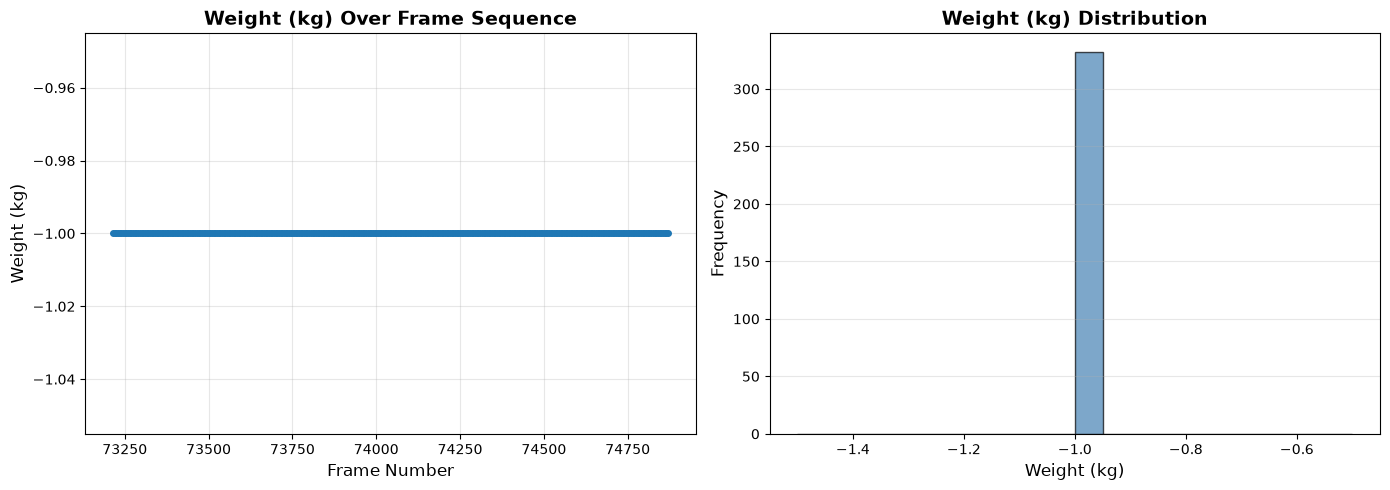


Summary Statistics:
Total frames analyzed: 332
Min weight: -1.00 kg
Max weight: -1.00 kg
Mean weight: -1.00 kg
Std deviation: 0.00 kg


In [79]:
FOLDER_PATH = "/home/gokul/defects/mr00389746/0704-0705"
visualize_weights(FOLDER_PATH)


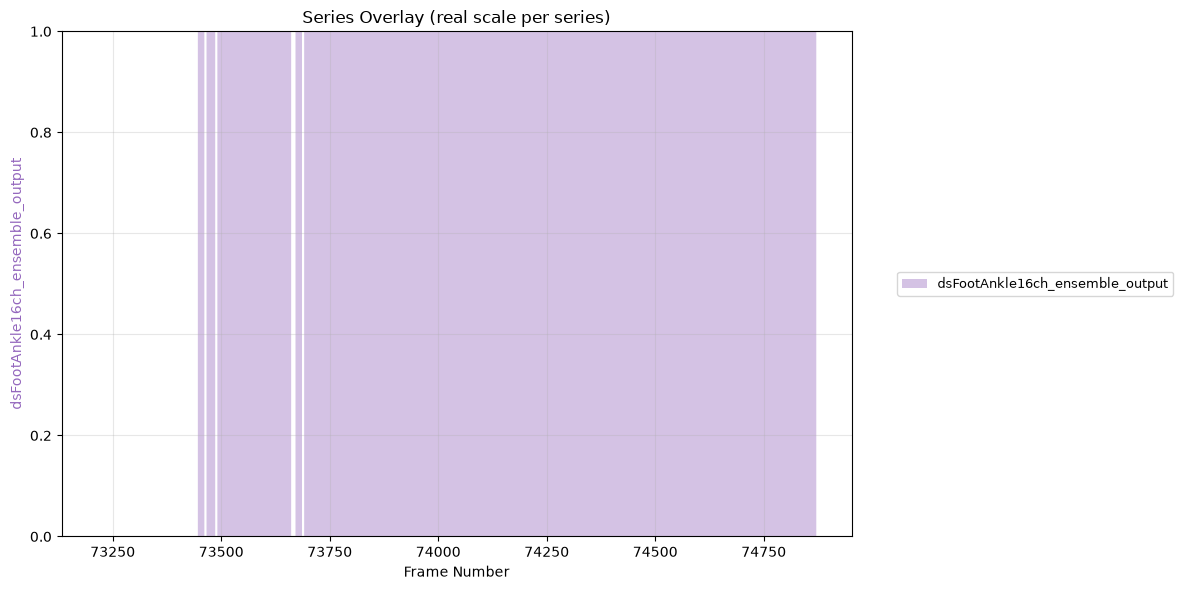

In [80]:
FOLDER_PATH = "/home/gokul/defects/mr00389746/0704-0705"
fig = plot_coil_detection(FOLDER_PATH, coils_dict_path="coils_dict.json");


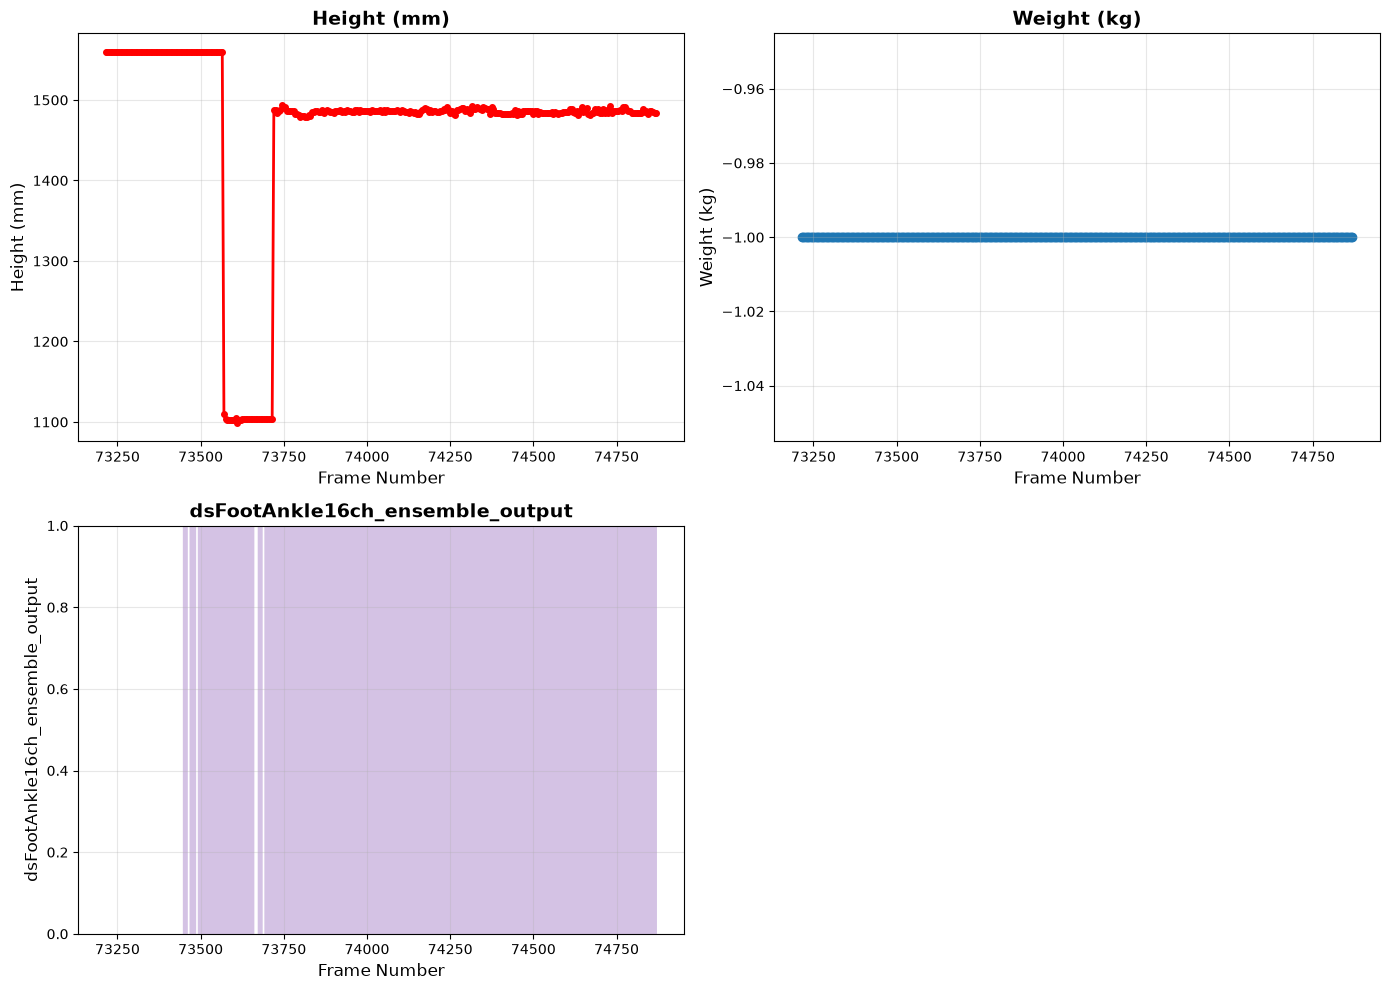

In [81]:
# Example: master grid function with multiple metrics, 2 subplots per row.
FOLDER_PATH = "/home/gokul/defects/mr00389746/0704-0705"

height_series = extract_patient_field_series(FOLDER_PATH, "height", "Height (mm)", color='red')
weight_series = extract_patient_field_series(FOLDER_PATH, "weight", "Weight (kg)", style="scatter")
coil_series_list = build_coil_series(FOLDER_PATH, coils_dict_path="coils_dict.json")

_ = plot_series_grid(height_series, weight_series, *coil_series_list, ncols=2);


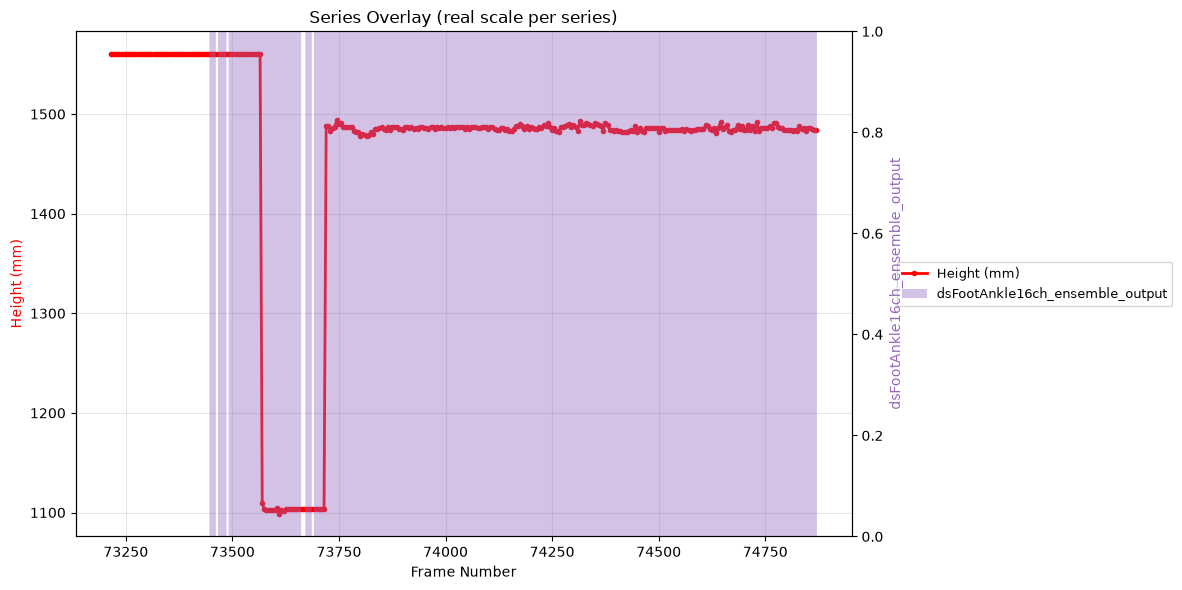

In [82]:
# Example: master overlay function combining a large-scale metric (height, mm) with a
# 0/1 metric (coil detection) on one plot, demonstrating auto twin-axis scaling.
first_coil_series = coil_series_list[0]
_ = plot_series_overlay(height_series, first_coil_series, max_real_scale_axes=2);


In [83]:
FOLDER_PATH = "/home/gokul/defects/MR00388757/iso_center_up_down_defect"

height_series = extract_patient_field_series(FOLDER_PATH, "height", "Height (mm)", color='red')
weight_series = extract_patient_field_series(FOLDER_PATH, "weight", "Weight (kg)", style="scatter")
coil_series_list = build_coil_series(FOLDER_PATH, coils_dict_path="coils_dict.json")

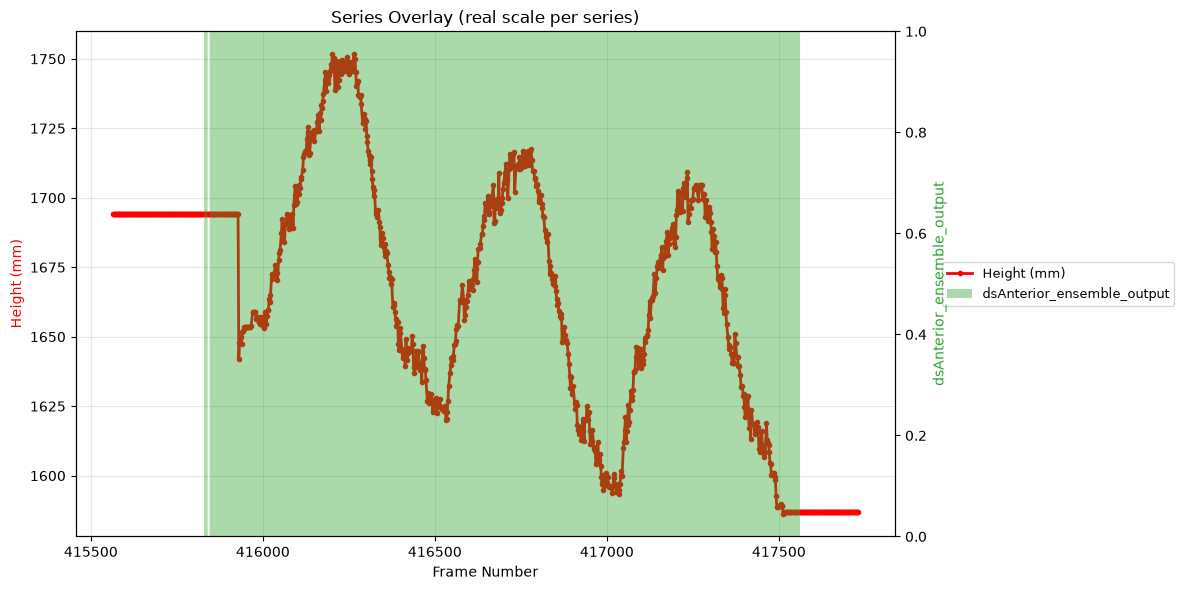

In [84]:
first_coil_series = coil_series_list[0]
_ = plot_series_overlay(height_series, first_coil_series, max_real_scale_axes=2);

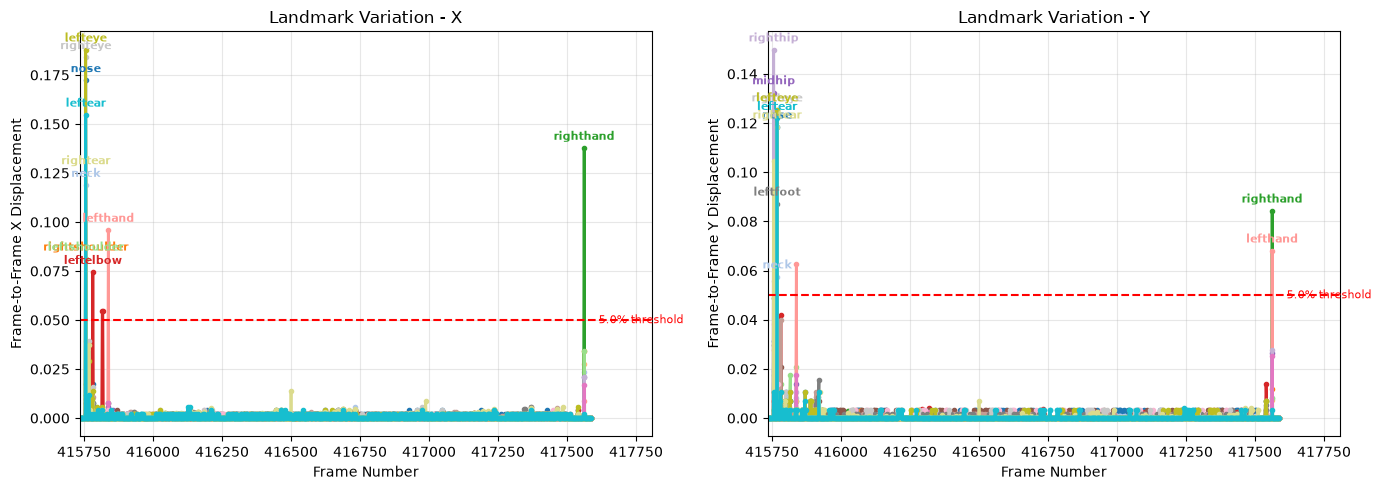

In [85]:
# Example: frame-to-frame landmark x/y variation, fixed colors per landmark, with a
# 5% threshold line (only landmarks crossing it are labeled, at their peak). The two
# split functions are composed side by side using the plot_series_grid master function.
import functools

# FOLDER_PATH = "/home/gokul/defects/mr00389746/0704-0705"
_ = plot_series_grid(
    functools.partial(plot_landmark_variation_x, FOLDER_PATH, threshold=0.05),
    functools.partial(plot_landmark_variation_y, FOLDER_PATH, threshold=0.05),
    ncols=2,
);


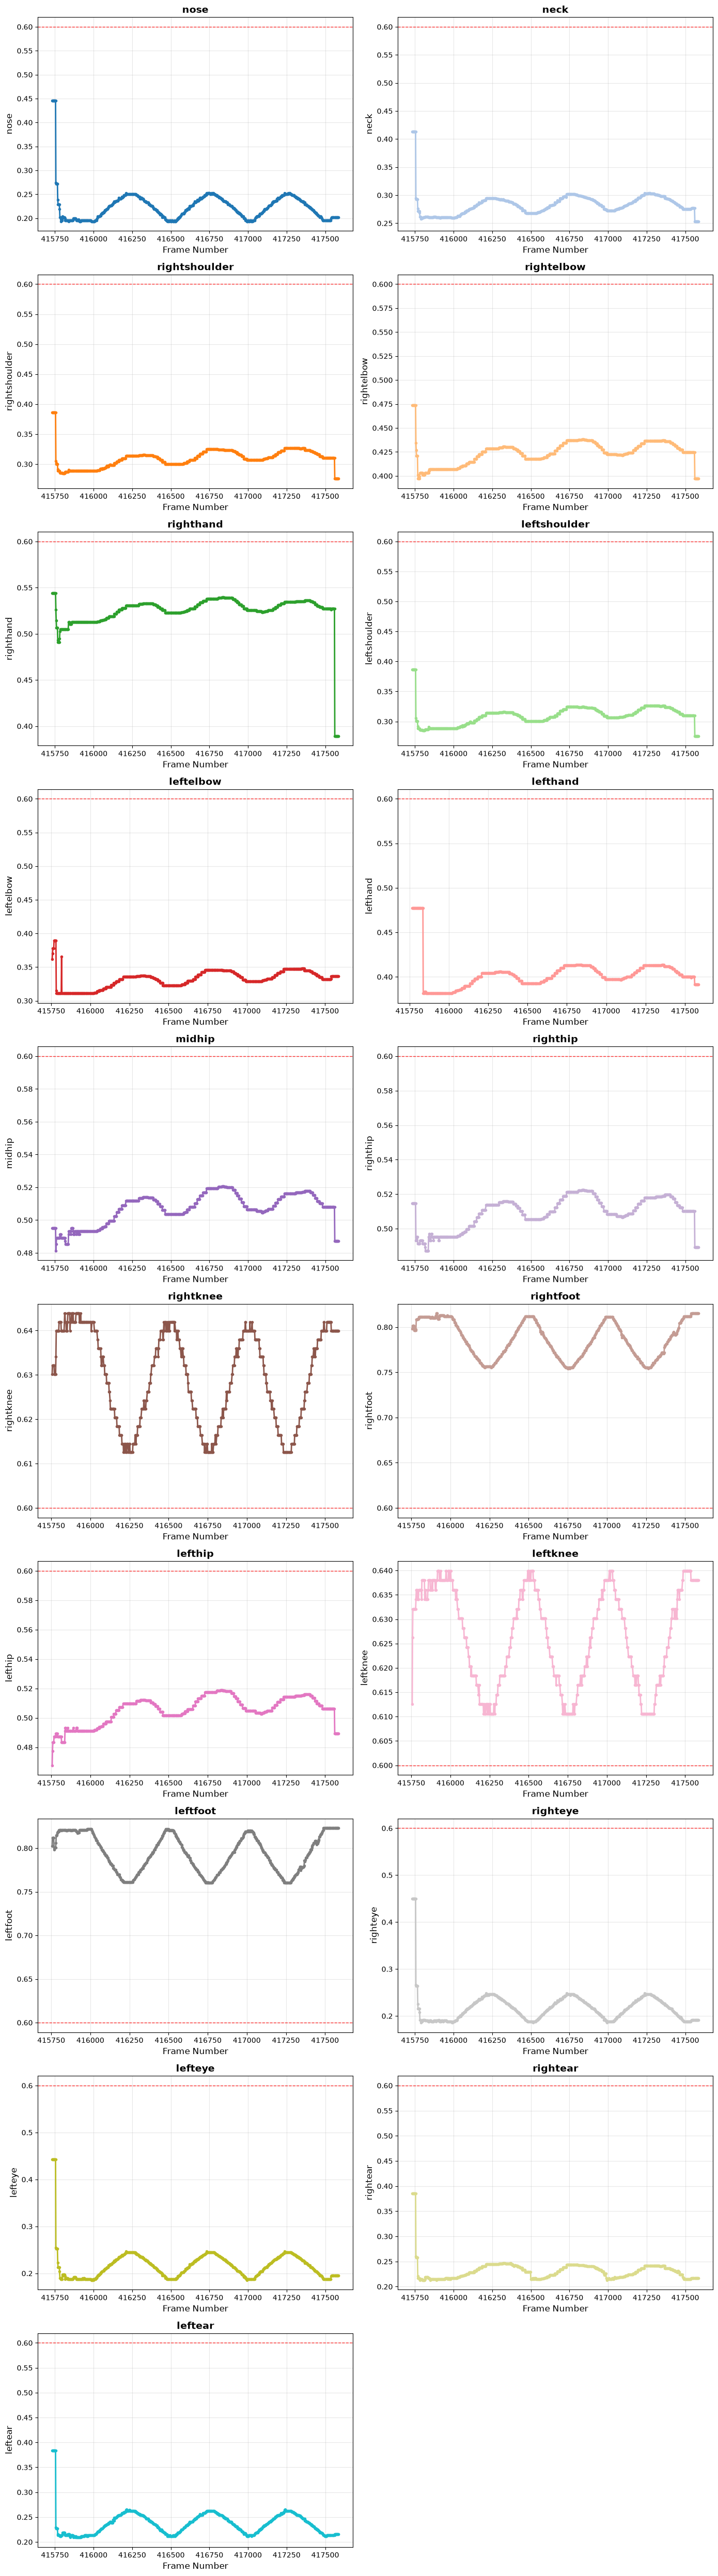

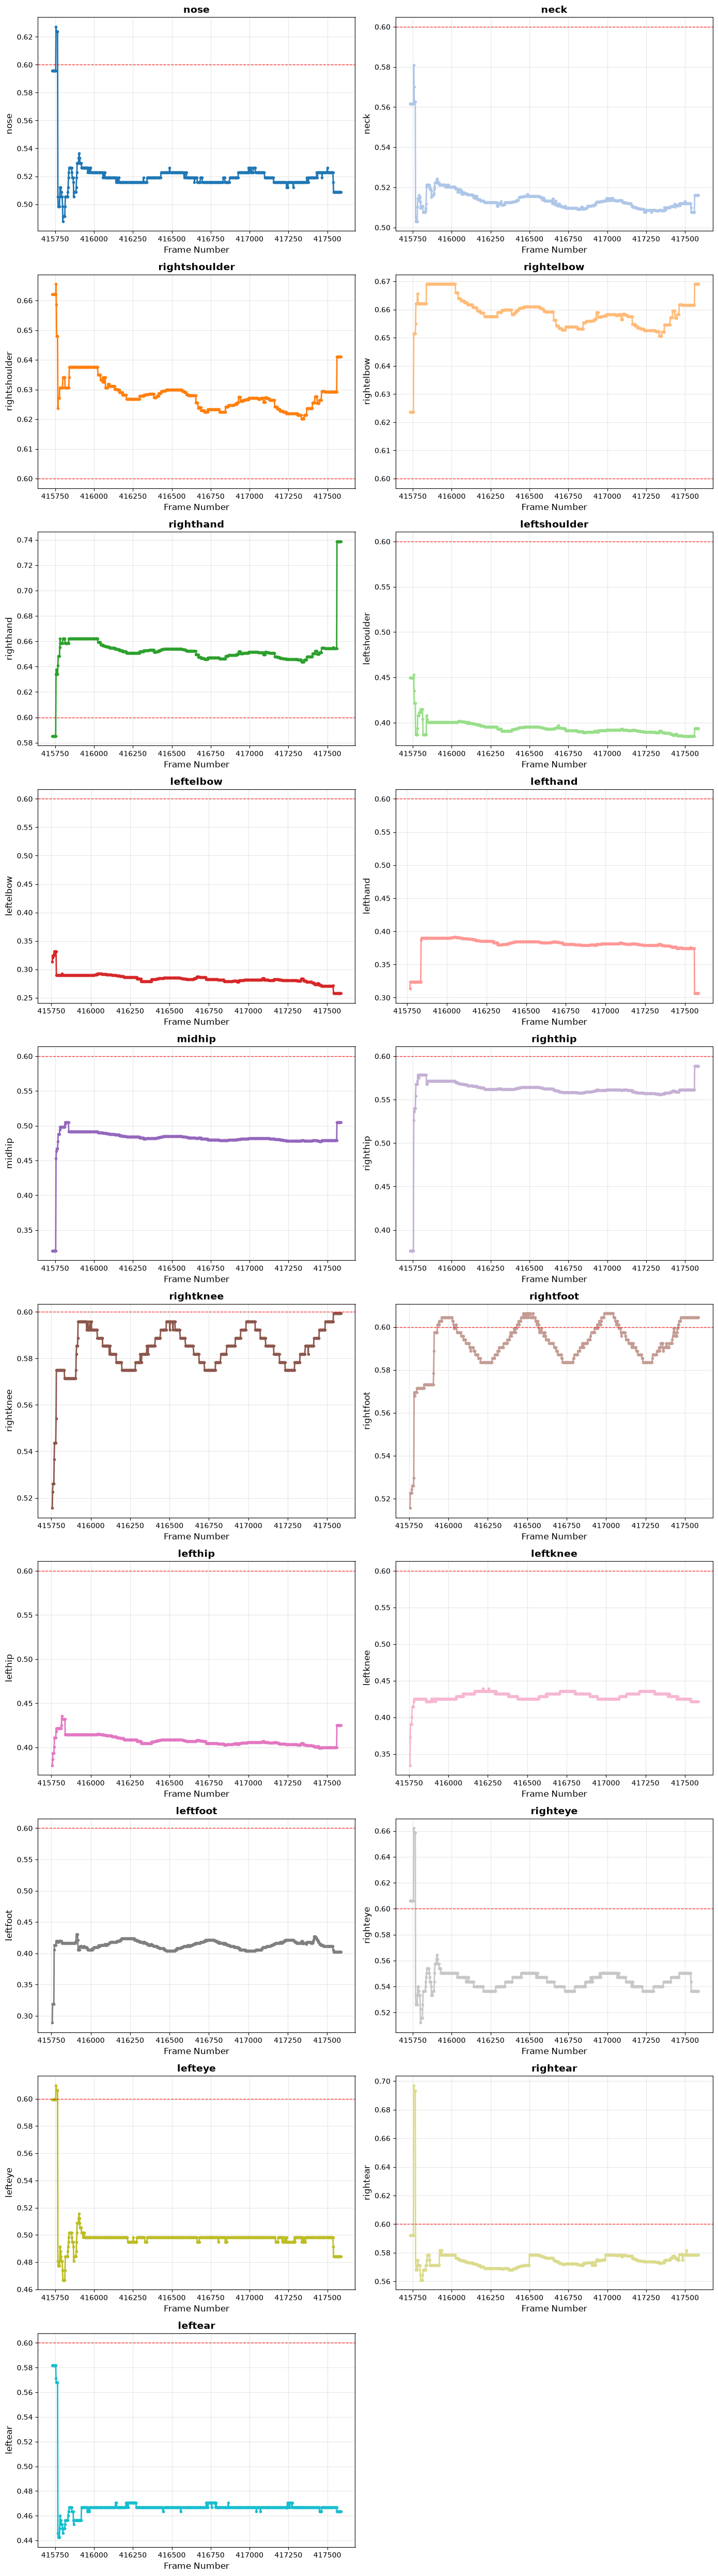

In [86]:
# Example: absolute (raw, normalized) landmark x/y position per frame - plotted as a
# series of subplots (one per landmark) via plot_series_grid, rather than overlaying
# every landmark onto a single shared axis.
# FOLDER_PATH = "/home/gokul/defects/mr00389746/0704-0705"
_ = plot_landmark_position_x(FOLDER_PATH, threshold=0.6)
_ = plot_landmark_position_y(FOLDER_PATH, threshold=0.6)
